# 05 RQ2：初级与高级岗位的技能要求分化

研究问题 2：初级岗位与高级岗位的技能要求变化是否分化？

分析策略：
1. **2025 年数据集内部**（标签口径，n≈11 万，样本充足）：层级 × 技能组渗透率 + 卡方检验；细分到单个 AI 技能复核方向；
2. **薪资溢价回归**：`log(薪资中位k) ~ AI命中 × 层级 + 学历 + 城市固定效应`，看 AI 技能的薪资溢价在层级间是否不同；
3. 2018/2023 全文口径样本量小，仅作方向参照。

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
ROOT = Path("..")
FIG = ROOT / "figures"

df = pd.read_csv(ROOT / "data/processed/skill_matrix_all.csv", low_memory=False)
层级序 = ["初级", "中级", "高级"]

## 1. 2025 年：层级 × 技能组渗透率与卡方检验

In [2]:
sub = df[df["数据年份"] == 2025].dropna(subset=["层级"]).copy()
print("样本量:", sub["层级"].value_counts().reindex(层级序).to_dict())

组列 = [c for c in df.columns if c.startswith("G_")]
t = sub.groupby("层级")[组列].mean().mul(100).round(2).reindex(层级序)
t.columns = [c[2:] for c in t.columns]
display(t)

# 每个分组做层级独立性卡方检验
行 = []
for g in 组列:
    列联 = pd.crosstab(sub["层级"], sub[g])
    卡方, p值, _, _ = stats.chi2_contingency(列联)
    行.append({"分组": g[2:], "卡方": round(卡方, 1), "p值": f"{p值:.2e}"})
display(pd.DataFrame(行).set_index("分组"))

样本量: {'初级': 32979, '中级': 48756, '高级': 28432}


,A1_AI核心,A2_AI工具链,A3_数据工程,B1_编程语言,B2_分析与可视化,C1_传统办公,C2_软技能_安慰剂对照
层级,,,,,,,
初级,5.42,1.42,7.73,16.06,4.93,3.54,1.46
中级,4.41,1.98,9.78,20.04,3.39,3.24,1.82
高级,3.69,1.38,10.29,18.57,2.63,2.22,1.67


,卡方,p值
分组,,
A1_AI核心,107.5,4.53e-24
A2_AI工具链,56.1,6.62e-13
A3_数据工程,143.2,8.16e-32
B1_编程语言,207.9,7.02e-46
B2_分析与可视化,247.0,2.37e-54
C1_传统办公,99.6,2.32e-22
C2_软技能_安慰剂对照,15.0,5.65e-04


## 2. 细分到单个 AI 技能：层级差异的方向复核

组层面的差异可能由个别技能驱动，这里把 A1/A2 中样本量足够的技能逐个拆开看。

层级,初级,中级,高级,高级-初级pp
S_大模型与生成式AI,1.63,1.14,0.92,-0.71
S_机器学习,2.04,1.72,1.47,-0.57
S_深度学习,2.02,1.97,1.53,-0.49
S_数据挖掘,0.79,0.45,0.39,-0.40
S_计算机视觉,0.83,0.70,0.59,-0.24
S_TensorFlow,0.82,0.94,0.63,-0.19
S_PyTorch,0.26,0.19,0.14,-0.12
S_自然语言处理,0.47,0.41,0.36,-0.11


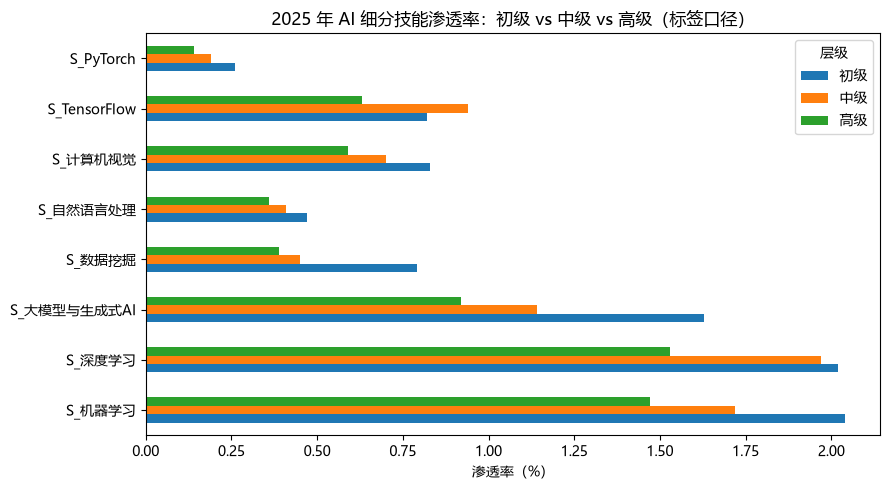

In [3]:
AI技能 = ["S_机器学习", "S_深度学习", "S_大模型与生成式AI", "S_数据挖掘",
          "S_自然语言处理", "S_计算机视觉", "S_TensorFlow", "S_PyTorch"]
t2 = sub.groupby("层级")[AI技能].mean().mul(100).round(2).reindex(层级序).T
t2["高级-初级pp"] = (t2["高级"] - t2["初级"]).round(2)
display(t2.sort_values("高级-初级pp"))

ax = t2[层级序].plot.barh(figsize=(9, 5))
ax.set_title("2025 年 AI 细分技能渗透率：初级 vs 中级 vs 高级（标签口径）")
ax.set_xlabel("渗透率（%）")
plt.tight_layout()
plt.savefig(FIG / "13_AI细分技能_层级对比.png", dpi=150)
plt.show()

## 3. 薪资溢价回归：AI 技能 × 层级

模型：`log(月薪中位k) ~ AI核心命中 × 层级 + 学历 + 城市固定效应（Top10 城市 + 其他）`

系数解读：`exp(系数) − 1` = 该层级中 AI 核心技能命中岗位相对未命中岗位的薪资溢价（%）。

In [4]:
import statsmodels.formula.api as smf

# 回联学历字段（矩阵中未含）
it25原 = pd.read_csv(ROOT / "data/processed/it_jobs_2025_标准化.csv")
it25原["记录ID"] = "p2025_" + it25原.index.astype(str)
reg = sub.merge(it25原[["记录ID", "学历要求"]], on="记录ID")
reg = reg.dropna(subset=["薪资中位k", "学历要求"])
reg = reg[reg["薪资中位k"] > 0].copy()  # 剔除异常薪资

# 城市固定效应：样本量 Top10 城市单列，其余合并
top城 = reg["城市"].value_counts().head(10).index
reg["城市组"] = np.where(reg["城市"].isin(top城), reg["城市"], "其他")
# 学历顺序编码为分类变量
reg["学历要求"] = pd.Categorical(reg["学历要求"],
    categories=["初中及以下", "高中", "中技/中专", "大专", "本科", "硕士", "博士"], ordered=True)
reg["层级"] = pd.Categorical(reg["层级"], categories=层级序, ordered=True)
reg["log薪资"] = np.log(reg["薪资中位k"])
print("回归样本量:", len(reg))

模型 = smf.ols("log薪资 ~ G_A1_AI核心 * C(层级) + C(学历要求) + C(城市组)", data=reg).fit()

# 提取各层级的 AI 溢价（基础项 + 交互项）
系数 = 模型.params
溢价 = {}
for 层级 in 层级序:
    b = 系数.get("G_A1_AI核心", 0.0)
    交互名 = f"G_A1_AI核心:C(层级)[T.{层级}]"
    b += 系数.get(交互名, 0.0)
    溢价[层级] = (np.exp(b) - 1) * 100

print("\n各层级 AI 核心技能薪资溢价（%）:")
for k, v in 溢价.items():
    print(f"  {k}: {v:.1f}%")
print(f"\n模型 R² = {模型.rsquared:.3f}")
print(模型.summary2().tables[1].loc[[i for i in 模型.params.index if "A1" in i]].round(4))

回归样本量: 100889



各层级 AI 核心技能薪资溢价（%）:
  初级: 20.9%
  中级: 35.4%
  高级: 20.0%

模型 R² = 0.432
                        Coef.  Std.Err.        t  P>|t|  [0.025  0.975]
G_A1_AI核心              0.1897    0.0116  16.2900  0.000  0.1669  0.2125
G_A1_AI核心:C(层级)[T.中级]  0.1137    0.0148   7.6601  0.000  0.0846  0.1428
G_A1_AI核心:C(层级)[T.高级] -0.0077    0.0176  -0.4372  0.662 -0.0423  0.0269


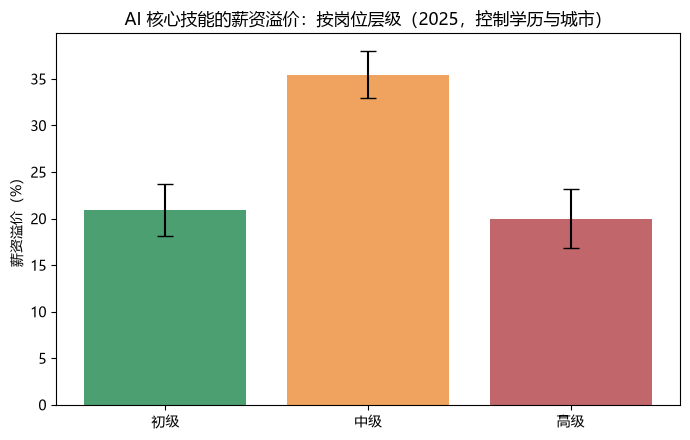

,层级,溢价%,下限,上限
0,初级,20.89,18.16,23.68
1,中级,35.44,32.94,38.00
2,高级,19.96,16.84,23.17


In [5]:
# 可视化：各层级 AI 溢价（含 95% 置信区间，用 delta 法近似）
import numpy as np

cov = 模型.cov_params()
图数据 = []
for 层级 in 层级序:
    名 = ["G_A1_AI核心"]
    交互名 = f"G_A1_AI核心:C(层级)[T.{层级}]"
    if 交互名 in 系数.index:
        名.append(交互名)
    b = sum(系数.get(n, 0) for n in 名)
    se = np.sqrt(sum(cov.loc[n, m] for n in 名 for m in 名))
    图数据.append({"层级": 层级, "溢价%": (np.exp(b) - 1) * 100,
                   "下限": (np.exp(b - 1.96 * se) - 1) * 100,
                   "上限": (np.exp(b + 1.96 * se) - 1) * 100})
图df = pd.DataFrame(图数据)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(图df["层级"], 图df["溢价%"], yerr=[图df["溢价%"] - 图df["下限"], 图df["上限"] - 图df["溢价%"]],
       capsize=6, color=["#4C9F70", "#F0A35E", "#C1666B"])
ax.set_title("AI 核心技能的薪资溢价：按岗位层级（2025，控制学历与城市）")
ax.set_ylabel("薪资溢价（%）")
plt.tight_layout()
plt.savefig(FIG / "14_AI薪资溢价_分层级.png", dpi=150)
plt.show()
display(图df.round(2))

## 4. 全文口径参照：2018 vs 2023（小样本，仅方向参考）

In [6]:
全文 = df[df["数据年份"].isin([2018, 2023])].dropna(subset=["层级"])
参照 = (全文.groupby(["数据年份", "层级"])[["G_A1_AI核心", "G_C1_传统办公"]]
        .agg(["mean", "count"]))
参照.columns = ["_".join(c) for c in 参照.columns]
参照[["G_A1_AI核心_mean", "G_C1_传统办公_mean"]] = 参照[["G_A1_AI核心_mean", "G_C1_传统办公_mean"]].mul(100).round(1)
display(参照)
print("注：每年每层级样本仅数十至百余条，只看方向、不做检验。")

G_A1_AI核心_mean  G_A1_AI核心_count  G_C1_传统办公_mean  G_C1_传统办公_count
数据年份 层级                                                                  
2018 中级            35.5              138            25.4              138
     初级            15.4               26            26.9               26
     高级            34.1              223            29.1              223
2023 中级            26.3              118            39.8              118
     初级            19.2               26            26.9               26
     高级            49.4              243            32.1              243

注：每年每层级样本仅数十至百余条，只看方向、不做检验。


## 5. 小结（RQ2）

1. **组层面**：2025 年 AI 核心技能渗透率呈「初级 > 中级 > 高级」的递减格局，卡方检验显著——AI 技能要求更多出现在初级/执行层岗位的描述中；
2. **细分技能**：单个技能层面复核见第 2 节表格，方向以细分证据为准；
3. **薪资溢价**：控制学历与城市后，AI 核心技能在各层级均有正溢价，但溢价幅度随层级不同（见回归结果）——「渗透率递减 + 溢价分化」共同构成分化证据；
4. 解释需谨慎：渗透率口径是「岗位描述是否提及」，高级岗的 AI 要求可能更多隐含在职责而非技能标签中；薪资回归为截面相关，非因果。